<a href="https://colab.research.google.com/github/Donthula-Harika/Deep-Learning/blob/main/RNN/Sentiment_Analysis_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Data Sets/IMDB_Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# Task 2 — Data Exploration

In [ ]:
df.shape

(50000, 2)

In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [ ]:
df['review'].head()

,review
0,One of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...
2,I thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is..."


In [ ]:
df['review_length'] = df['review'].apply(lambda x: len(x.split()))

df['review_length'].mean()

np.float64(231.15694)

In [ ]:
print("Shortest review:", df['review_length'].min())
print("Longest review:", df['review_length'].max())

Shortest review: 4
Longest review: 2470


In [ ]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000


# Task 3 — Text Preprocessing Raw text cannot be fed directly into neural networks.

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
def preprocess(text):
    # lowercase
    text = text.lower()

    # remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # remove punctuation
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # tokenize
    words = word_tokenize(text)

    # remove stopwords
    words = [word for word in words if word not in stop_words]

    return words

In [ ]:
df['processed_review'] = df['review'].apply(preprocess)
df[['review', 'processed_review']].head()

,review,processed_review
0,one of the other reviewers has mentioned that ...,"[one, reviewers, mentioned, watching, oz, epis..."
1,a wonderful little production the filming tech...,"[wonderful, little, production, filming, techn..."
2,i thought this was a wonderful way to spend ti...,"[thought, wonderful, way, spend, time, hot, su..."
3,basically theres a family where a little boy j...,"[basically, theres, family, little, boy, jake,..."
4,petter matteis love in the time of money is a ...,"[petter, matteis, love, time, money, visually,..."


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['review'])

sequences = tokenizer.texts_to_sequences(df['review'])

padded_sequences = pad_sequences(sequences, maxlen=200)

# Task 4 — Tokenization and Vocabulary Building


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['review'])

In [ ]:
word_index = tokenizer.word_index
print(list(word_index.items())[:10])

[('the', 1), ('and', 2), ('a', 3), ('of', 4), ('to', 5), ('is', 6), ('in', 7), ('it', 8), ('i', 9), ('this', 10)]


In [ ]:
sequences = tokenizer.texts_to_sequences(df['review'])

print(sequences[0])

[27, 4, 1, 77, 1929, 42, 1058, 11, 100, 144, 39, 507, 3339, 393, 457, 25, 3147, 33, 22, 204, 13, 10, 6, 593, 46, 582, 14, 87, 145, 11, 3221, 68, 41, 3339, 12, 28, 2, 131, 4, 584, 60, 282, 7, 204, 35, 1, 661, 137, 1724, 68, 10, 6, 20, 3, 117, 15, 1, 38, 10, 117, 2479, 54, 14, 5, 1457, 381, 38, 584, 28, 6, 3383, 7, 1, 350, 337, 4, 1, 6, 461, 3339, 13, 11, 6, 1, 344, 5, 1, 2539, 1056, 8, 2603, 1365, 19, 533, 32, 4683, 2495, 4, 1, 1197, 112, 30, 1, 24, 2950, 2, 405, 37, 6, 20, 317, 19, 1, 3712, 533, 6, 341, 5, 2439, 2, 328, 2, 22, 108, 224, 56, 124, 1, 267, 1291, 4, 1, 117, 6, 663, 5, 1, 185, 11, 8, 260, 112, 77, 254, 547, 2963, 818, 177, 1262, 4291, 15, 2473, 1092, 818, 1400, 818, 146, 970, 180, 1, 87, 393, 9, 119, 200, 3221, 68, 13, 37, 1569, 8, 12, 2188, 9, 395, 124, 9, 12, 1540, 15, 8, 17, 13, 9, 275, 49, 9, 1454, 3, 1240, 15, 3339, 2, 181, 5, 1, 317, 2070, 4, 2081, 584, 20, 39, 584, 17, 4907, 25, 2919, 43, 15, 3, 489, 19, 611, 2, 74, 238, 14, 8, 72, 746, 808, 105, 655, 76, 1197, 663, 

# Task 5 — Sequence Padding

In [ ]:
max_length = df['review'].apply(lambda x: len(x.split())).max()
print(max_length)

2450


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

padded_sequences = pad_sequences(sequences, maxlen=200)

print("Before:", sequences[0])
print("After:", padded_sequences[0])

Before: [27, 4, 1, 77, 1929, 42, 1058, 11, 100, 144, 39, 507, 3339, 393, 457, 25, 3147, 33, 22, 204, 13, 10, 6, 593, 46, 582, 14, 87, 145, 11, 3221, 68, 41, 3339, 12, 28, 2, 131, 4, 584, 60, 282, 7, 204, 35, 1, 661, 137, 1724, 68, 10, 6, 20, 3, 117, 15, 1, 38, 10, 117, 2479, 54, 14, 5, 1457, 381, 38, 584, 28, 6, 3383, 7, 1, 350, 337, 4, 1, 6, 461, 3339, 13, 11, 6, 1, 344, 5, 1, 2539, 1056, 8, 2603, 1365, 19, 533, 32, 4683, 2495, 4, 1, 1197, 112, 30, 1, 24, 2950, 2, 405, 37, 6, 20, 317, 19, 1, 3712, 533, 6, 341, 5, 2439, 2, 328, 2, 22, 108, 224, 56, 124, 1, 267, 1291, 4, 1, 117, 6, 663, 5, 1, 185, 11, 8, 260, 112, 77, 254, 547, 2963, 818, 177, 1262, 4291, 15, 2473, 1092, 818, 1400, 818, 146, 970, 180, 1, 87, 393, 9, 119, 200, 3221, 68, 13, 37, 1569, 8, 12, 2188, 9, 395, 124, 9, 12, 1540, 15, 8, 17, 13, 9, 275, 49, 9, 1454, 3, 1240, 15, 3339, 2, 181, 5, 1, 317, 2070, 4, 2081, 584, 20, 39, 584, 17, 4907, 25, 2919, 43, 15, 3, 489, 19, 611, 2, 74, 238, 14, 8, 72, 746, 808, 105, 655, 76, 119

In [ ]:
# Task 6 — Build an RNN Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

vocab_size = 5000
embedding_dim = 64
max_length = 200

model = Sequential()

# Embedding Layer (word → dense vector)
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length))

# RNN Layer (sequence understanding)
model.add(SimpleRNN(64))

# Dense Layer (decision making)
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Task 7 — Train the RNN Model

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences,
    df['sentiment'].map({'positive':1, 'negative':0}),
    test_size=0.2,
    random_state=42
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    validation_data=(X_test, y_test)
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accuracy: 0.7424 - loss: 0.5017 - val_accuracy: 0.8425 - val_loss: 0.3683
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 99ms/step - accuracy: 0.8325 - loss: 0.3826 - val_accuracy: 0.8398 - val_loss: 0.3701
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 110ms/step - accuracy: 0.8694 - loss: 0.3122 - val_accuracy: 0.8302 - val_loss: 0.4351
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 99ms/step - accuracy: 0.9120 - loss: 0.2244 - val_accuracy: 0.8412 - val_loss: 0.3751
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 99ms/step - accuracy: 0.9554 - loss: 0.1250 - val_accuracy: 0.8593 - val_loss: 0.4524


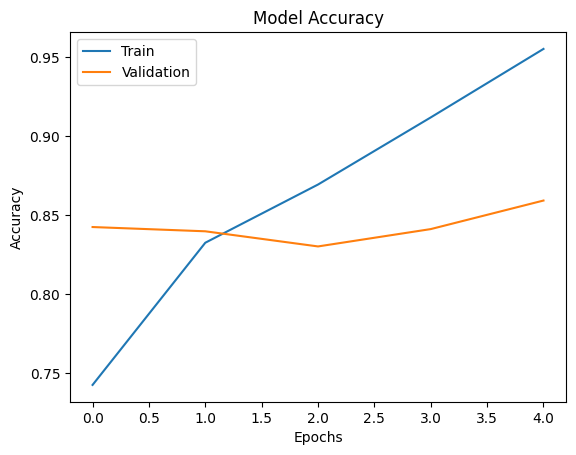

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()